In [ ]:
!pip install control

import control as sc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 11.4 MB/s eta 0:00:00


## comandos (Python / control)

- **tic / toc**: funciones para medir tiempo transcurrido similar a MATLAB
- **time**: modulo para manejar tiempo
- **tf**: crea un modelo  **funcion de transferencia**
- **ss**: crea un modelo  **espacio de estados**
- **zpk**: crea un modelo en forma **ceros-polos-ganancia**
- **tf2ss**: convierte de funcion de transferencia a espacio de estados.
- **tf2zp**: convierte de funcion de transferencia a ceros, polos y ganancia
- **ss2zp**: convierte de espacio de estados a ceros, polos y ganancia
- **ss2tf**: convierte de espacio de estados a funcion de transferencia
- **zp2ss**: convierte de ceros, polos y ganancia a espacio de estados
- **zp2tf**: convierte de ceros, polos y ganancia a funcion de transferencia
- **roots**: calcula las raices de un polinomio
- **pole**: obtiene los polos del sistema
- **zero**: obtiene los ceros del sistema
- **poly**: construye un polinomio a partir de sus raices
- **eig**: calcula autovalores de una matriz
- **pzmap**: grafica polos y ceros en el plano complejo
- **minreal**: elimina cancelaciones polo-cero y obtiene una realizacion minima.
- **subplot**: crea varias subgraficas en una misma figura
- **feedback**: forma un lazo de realimentacion abierto/cerrado
- **tfdata**: extrae numerador y denominador de un modelo `tf`

Documentacion: https://python-control.readthedocs.io/en/0.10.1/index.html

> Nota: para este notebook se usara `python-control` con `import control as sc`.
> Los comandos de esta guia se invocan tipicamente como `sc.tf`, `sc.ss`, `sc.pole`.

## 3.3 Respuestas conceptuales

- **¿Qué es el polinomio característico de un sistema?**  
  Es el polinomio que se obtiene de $\det(sI-A)=0$ en espacio de estados (o del denominador de la función de transferencia en sistemas LTI). Sus raíces determinan la dinámica natural del sistema.

- **¿Qué son los valores propios de un sistema?**  
  Son los escalares $\lambda$ que satisfacen $Av=\lambda v$ para algún vector no nulo $v$. En control, corresponden a los polos del sistema (en realización mínima) y definen estabilidad, rapidez y tipo de respuesta.

- **¿Qué son el tiempo de estabilización y el sobre nivel porcentual en la respuesta al escalón?**  
  - **Tiempo de estabilización ($T_s$)**: tiempo que tarda la salida en entrar y permanecer dentro de una banda de tolerancia alrededor del valor final (típicamente $\pm2\%$ o $\pm5\%$).  
  - **Sobre nivel porcentual ($\%OS$)**: cuánto supera el pico máximo al valor final, en porcentaje:
  $$
  \%OS = \frac{y_{\max}-y_{\infty}}{y_{\infty}}\times 100
  $$
  Mide el grado de sobreimpulso de la respuesta transitoria.

## 5.1

Supongamos que experimentamos con el sistema, el cual se encuentra en operacion estable, y que lo sometemos a un cambio en la senal de entrada $u(t)$. Esto produce un cambio en el punto de operacion del sistema y, como consecuencia, un cambio en la senal de respuesta $y(t)$.

Despues de un procedimiento matematico, con base en las senales experimentales, se obtiene para el sistema un modelo en forma de Funcion de Transferencia (FT):

$$
G(s)=\frac{k e^{-sT_m}}{(\tau_1 s+1)(\tau_2 s+1)}
=\frac{1.2\,e^{-39.2s}}{(59.7s+1)(22.3s+1)}
$$

Donde:
- $T_m$: tiempo muerto
- $k$: ganancia del sistema
- $\tau_1,\tau_2$: constantes de tiempo

Este modelo de segundo orden con tiempo muerto (MSOTM) tiene una respuesta al escalon que se superpone a la del sistema original. El tiempo muerto $T_m=39.2\,s$ desplaza en el tiempo la respuesta del modelo en esa cantidad.

### 5.1 Conversion FT -> EE (sin tiempo muerto)

Partimos del modelo sin tiempo muerto:

$$
G_0(s)=\frac{k}{(\tau_1 s+1)(\tau_2 s+1)}
=\frac{k}{\tau_1\tau_2 s^2+(\tau_1+\tau_2)s+1}
$$

Relacion entrada-salida:

$$
\left(\tau_1\tau_2 s^2+(\tau_1+\tau_2)s+1\right)Y(s)=kU(s)
$$

En tiempo continuo:

$$
\tau_1\tau_2\,\ddot y(t)+(\tau_1+\tau_2)\,\dot y(t)+y(t)=k\,u(t)
$$

Con coeficiente de la mayor derivada igual a 1:

$$
\ddot y(t)+\frac{\tau_1+\tau_2}{\tau_1\tau_2}\dot y(t)+\frac{1}{\tau_1\tau_2}y(t)=\frac{k}{\tau_1\tau_2}u(t)
$$

Usando Variables de Estado de Fase (VEF):

$$
x_1(t)=y(t),\quad x_2(t)=\dot y(t)
$$

Se obtiene:

$$
\dot x_1=x_2
$$

$$
\dot x_2=-\frac{1}{\tau_1\tau_2}x_1-\frac{\tau_1+\tau_2}{\tau_1\tau_2}x_2+\frac{k}{\tau_1\tau_2}u
$$

$$
y=x_1
$$

Forma matricial:

$$
\dot x=Ax+Bu,\quad y=Cx+Du
$$

$$
A=\begin{bmatrix}
0 & 1\\
-\frac{1}{\tau_1\tau_2} & -\frac{\tau_1+\tau_2}{\tau_1\tau_2}
\end{bmatrix},\quad
B=\begin{bmatrix}
0\\
\frac{k}{\tau_1\tau_2}
\end{bmatrix},\quad
C=\begin{bmatrix}1 & 0\end{bmatrix},\quad
D=\begin{bmatrix}0\end{bmatrix}
$$

Modelo de FT sin tiempo muerto:

$$
G_0(s)=\frac{k}{(\tau_1 s+1)(\tau_2 s+1)}
$$

Modelo de EE sin tiempo muerto:

$$
\dot x_1=x_2,\qquad
\dot x_2=-\frac{1}{\tau_1\tau_2}x_1-\frac{\tau_1+\tau_2}{\tau_1\tau_2}x_2+\frac{k}{\tau_1\tau_2}u,\qquad
y=x_1
$$

## 5.2 Implementacion en Python (sin tiempo muerto)

Ahora se define en Python el modelo sin tiempo muerto en sus dos formas:

- Funcion de transferencia: `Gptf = sc.tf(num, den)`
- Espacio de estado: `Mpss = sc.ss(A, B, C, D)`

Luego se comparan las respuestas al escalon de `0.23*Gptf` y `0.23*Mpss`, y se obtienen:

- Valor final de la respuesta (5.2.1)
- Tiempo de estabilizacion (5.2.2)

Gptf =
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          1.2
  -------------------
  1331 s^2 + 82 s + 1

Mpss =
<StateSpace>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[ 0.00000000e+00  1.00000000e+00]
     [-7.51139855e-04 -6.15934681e-02]]

B = [[0.        ]
     [0.00090137]]

C = [[1. 0.]]

D = [[0.]]


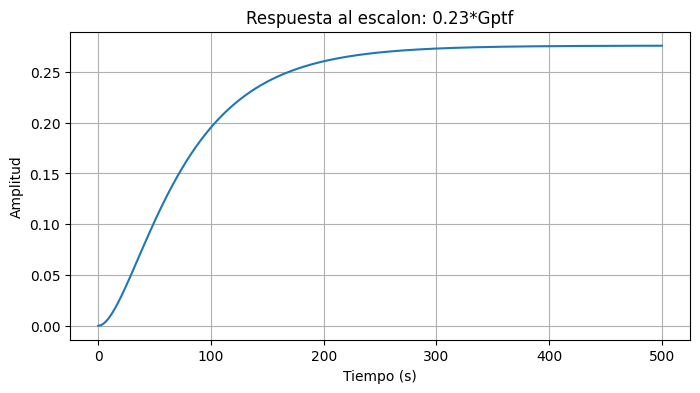

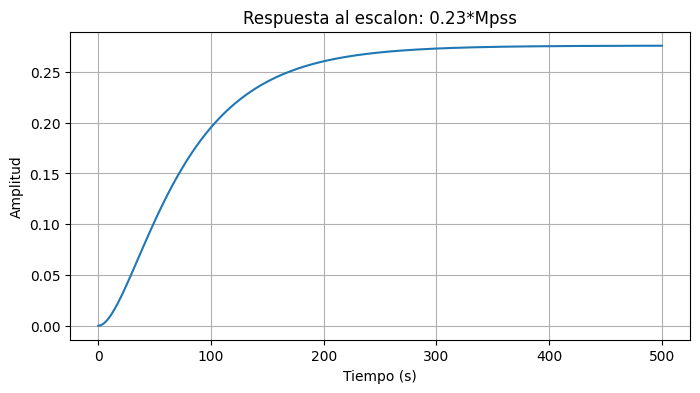

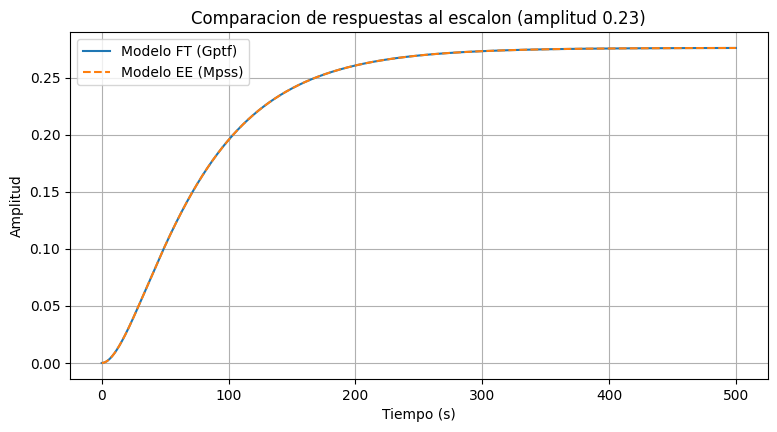


--- Resultados 5.2.1 y 5.2.2 ---
Valor final FT (DC gain * 0.23): 0.276000
Valor final EE (DC gain * 0.23): 0.276000
Valor final esperado = 0.23*k = 0.276000
Tiempo de estabilizacion FT (2%): 261.592568 s
Tiempo de estabilizacion EE (2%): 261.592568 s

Step info FT: {'RiseTime': 144.64530251713418, 'SettlingTime': 261.5925683820512, 'SettlingMin': 0.2488648970247613, 'SettlingMax': 0.276, 'Overshoot': 0.0, 'Undershoot': 0.0, 'Peak': 0.27555943468599936, 'PeakTime': 412.3929901552336, 'SteadyStateValue': 0.276}
Step info EE: {'RiseTime': 144.64530251713418, 'SettlingTime': 261.5925683820512, 'SettlingMin': 0.2488648970247615, 'SettlingMax': 0.276, 'Overshoot': 0.0, 'Undershoot': 0.0, 'Peak': 0.2755594346859983, 'PeakTime': 412.3929901552336, 'SteadyStateValue': 0.276}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros del modelo sin tiempo muerto
k = 1.2
tau1 = 59.7
tau2 = 22.3

# FT: G0(s) = k / ((tau1*s+1)(tau2*s+1))
num = [k]
den = np.polymul([tau1, 1], [tau2, 1])

# EE en variables de estado de fase: x1=y, x2=dy/dt
A = np.array([
    [0, 1],
    [-1/(tau1*tau2), -(tau1+tau2)/(tau1*tau2)]
], dtype=float)
B = np.array([[0], [k/(tau1*tau2)]], dtype=float)
C = np.array([[1, 0]], dtype=float)
D = np.array([[0]], dtype=float)

# Modelos
Gptf = sc.tf(num, den)
Mpss = sc.ss(A, B, C, D)

print('Gptf =')
print(Gptf)
print('\nMpss =')
print(Mpss)

# Entrada escalon de amplitud 0.23
amp = 0.23
Gptf_amp = amp * Gptf
Mpss_amp = amp * Mpss

# Tiempo de simulacion
T = np.linspace(0, 500, 2000)

# Respuesta al escalon
T_tf, y_tf = sc.step_response(Gptf_amp, T)
T_ss, y_ss = sc.step_response(Mpss_amp, T)

# Graficas solicitadas (equivalente a step + figure + step)
plt.figure(figsize=(8, 4))
plt.plot(T_tf, y_tf)
plt.title('Respuesta al escalon: 0.23*Gptf')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure(figsize=(8, 4))
plt.plot(T_ss, y_ss)
plt.title('Respuesta al escalon: 0.23*Mpss')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Comparacion superpuesta
plt.figure(figsize=(9, 4.5))
plt.plot(T_tf, y_tf, label='Modelo FT (Gptf)')
plt.plot(T_ss, y_ss, '--', label='Modelo EE (Mpss)')
plt.title('Comparacion de respuestas al escalon (amplitud 0.23)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

# 5.2.1 y 5.2.2 con step_info
info_tf = sc.step_info(Gptf_amp)
info_ss = sc.step_info(Mpss_amp)

print('\n--- Resultados 5.2.1 y 5.2.2 ---')
print(f'Valor final FT (DC gain * 0.23): {sc.dcgain(Gptf_amp):.6f}')
print(f'Valor final EE (DC gain * 0.23): {sc.dcgain(Mpss_amp):.6f}')
print(f'Valor final esperado = 0.23*k = {amp*k:.6f}')
print(f'Tiempo de estabilizacion FT (2%): {info_tf["SettlingTime"]:.6f} s')
print(f'Tiempo de estabilizacion EE (2%): {info_ss["SettlingTime"]:.6f} s')

# Diccionarios completos por si se requieren mas metricas
print('\nStep info FT:', info_tf)
print('Step info EE:', info_ss)

## 5.3 Agregar tiempo muerto a los modelos - aproximacion de Pade

En MATLAB se usa `get` para inspeccionar la informacion de una estructura.
En Python se puede usar
`print(modelo)` o `vars(modelo)`
para ver los campos internos.

### 5.3.1 Pade

En Python no existe `InputDelay` ni `OutputDelay` directamente en `python-control`, por lo que se aproxima el tiempo muerto mediante la aproximacion de **Pade**:

$$e^{-sT_m} \approx \frac{N_{pade}(s)}{D_{pade}(s)}$$

Se usa `sc.pade(Tm, n)` que devuelve `(num_pade, den_pade)` de orden `n`. Luego se multiplica al modelo original:

$$G_{ptfm}(s) = G_0(s)\cdot G_{pade}(s), \qquad M_{pssm} = G_{ptfm}(s) \text{ convertido a EE}$$

In [ ]:
# ---- Inspeccion de modelos ----
print('=' * 55)
print('Informacion de Gptf (Funcion de Transferencia):')
print('=' * 55)
print(Gptf)

print('\n' + '=' * 55)
print('Informacion de Mpss (Espacio de Estado):')
print('=' * 55)
print(Mpss)

# ---- Aproximacion de Pade para el tiempo muerto ----
Tm = 39.2
n_pade = 3   # orden de la aproximacion entre mayor n => mejor precision

num_pade, den_pade = sc.pade(Tm, n_pade)
Gpade = sc.tf(num_pade, den_pade)

print('\nAproximacion de Pade (orden {}):'.format(n_pade))
print(Gpade)

# ---- Modelos con tiempo muerto ----
Gptfm = Gptf * Gpade           # FT con tiempo muerto -Pade
Mpssm = sc.ss(Mpss * Gpade)    # EE con tiempo muerto - Pade, convertido a SS

print('\n' + '=' * 55)
print('Gptfm: FT con tiempo muerto (Pade):')
print('=' * 55)
print(Gptfm)

print('\n' + '=' * 55)
print('Mpssm: EE con tiempo muerto (Pade):')
print('=' * 55)
print(Mpssm)

Informacion de Gptf (Funcion de Transferencia):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          1.2
  -------------------
  1331 s^2 + 82 s + 1

Informacion de Mpss (Espacio de Estado):
<StateSpace>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[ 0.00000000e+00  1.00000000e+00]
     [-7.51139855e-04 -6.15934681e-02]]

B = [[0.        ]
     [0.00090137]]

C = [[1. 0.]]

D = [[0.]]

Aproximacion de Pade (orden 3):
<TransferFunction>: sys[8]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -s^3 + 0.3061 s^2 - 0.03905 s + 0.001992
  ----------------------------------------
  s^3 + 0.3061 s^2 + 0.03905 s + 0.001992

Gptfm: FT con tiempo muerto (Pade):
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            -1.2 s^3 + 0.3673 s^2 - 0.04686 s + 0.002391
  -----------------------------------------------------------------
  1331 s^5 + 489.5 s^4 + 78.08 s^3 + 6.16 s^2 + 0.2024 s + 0.001992

Mpssm: EE

### 5.3.2 Respuestas al escalon con tiempo muerto (subplot)

Se grafica en una misma figura con dos ventanas verticales la respuesta al escalon de amplitud `0.23` de cada modelo con tiempo muerto.

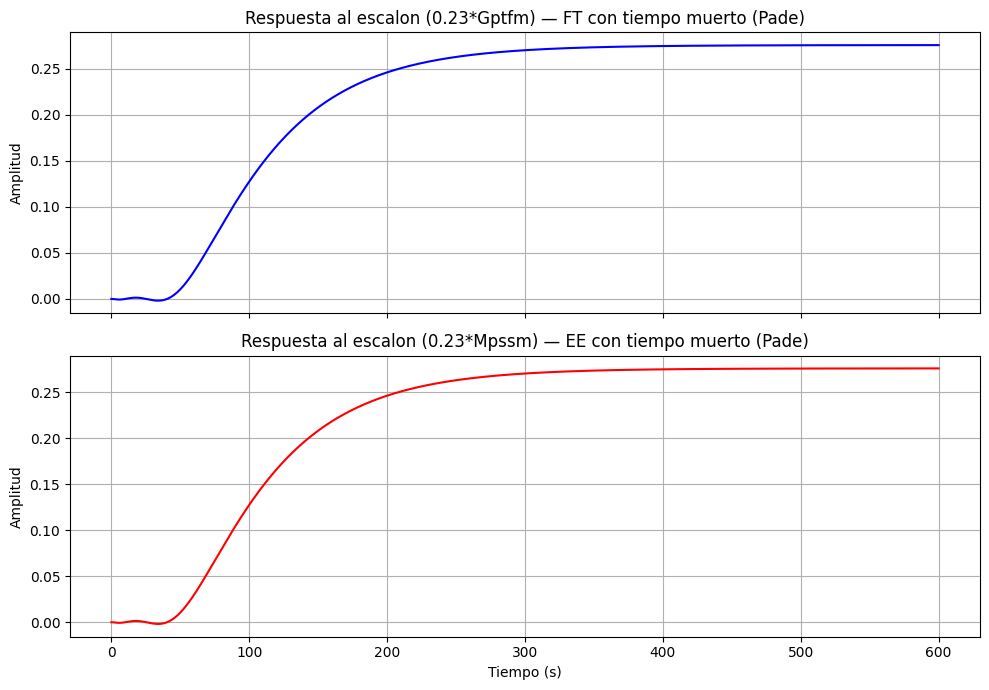

In [ ]:
amp = 0.23
T  = np.linspace(0, 600, 6000)

T1, y1 = sc.step_response(amp * Gptfm, T)
T2, y2 = sc.step_response(amp * Mpssm, T)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Ventana 1 – Gptfm (FT con tiempo muerto Pade)
axes[0].plot(T1, y1, 'b', linewidth=1.5)
axes[0].set_title('Respuesta al escalon (0.23*Gptfm) — FT con tiempo muerto (Pade)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True)

# Ventana 2 – Mpssm (EE con tiempo muerto Pade)
axes[1].plot(T2, y2, 'r', linewidth=1.5)
axes[1].set_title('Respuesta al escalon (0.23*Mpssm) — EE con tiempo muerto (Pade)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Comentario: ambas respuestas deben ser identicas (misma dinamica);
# el tiempo muerto de Tm=39.2 s se observa como retardo en el inicio de la respuesta.

### 5.3.3 Extraccion de datos al espacio de trabajo (ETPython)

Se leen los campos de las estructuras con tiempo muerto y se guardan en variables con nombres en mayuscula.

### 5.3.4 Ceros, polos, valores propios, polinomio caracteristico y ganancia DC

Se usa el modelo sin tiempo muerto para calcular las propiedades dinamicas del sistema.

In [ ]:
# --- Desde Gptfm (FT con tiempo muerto) ---
NUM_list, DEN_list = sc.tfdata(Gptfm)
NUM = np.array(NUM_list[0][0])   # nmerador
DEN = np.array(DEN_list[0][0])   # denominador
TM  = Tm                         # tiempo muerto

# --- Desde Mpssm (EE con tiempo muerto) ---
A_MAT = Mpssm.A
B_MAT = Mpssm.B
C_MAT = Mpssm.C
D_MAT = Mpssm.D

print('=== 5.3.3 ===')
print(f'NUM = {NUM}')
print(f'DEN = {DEN}')
print(f'TM  = {TM} s')
print(f'A =\n{A_MAT}')
print(f'B =\n{B_MAT}')
print(f'C =  {C_MAT}')
print(f'D =  {D_MAT}')

# --- 5.3.4  Propiedades del sistema (modelo sin tiempo muerto)

print('\n=== 5.3.4 ===')

ceros  = sc.zeros(Gptf)
polos  = sc.poles(Gptf)
eigval = np.linalg.eigvals(Mpss.A)
p_car  = np.poly(polos)          # polinomio caracteristico
dc     = float(sc.dcgain(Gptf))  # ganancia DC

print(f'Ceros del sistema:              {ceros}')
print(f'Polos del sistema:              {polos}')
print(f'Valores propios de A:           {eigval}')
print(f'Polinomio caracteristico:       {np.round(p_car, 6)}')
print(f'Ganancia DC (frecuencia cero):  {dc:.6f}')

=== 5.3.3 ===
NUM = [-1.2         0.36734694 -0.04685548  0.00239059]
DEN = [1.33131000e+03 4.89543878e+02 7.80846783e+01 6.16008875e+00
 2.02402910e-01 1.99215463e-03]
TM  = 39.2 s
A =
[[-3.06122449e-01 -3.90462307e-02 -1.99215463e-03  0.00000000e+00
   0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00]
 [ 5.51857852e-04  0.00000000e+00  3.59132817e-06 -7.51139855e-04
  -6.15934681e-02]]
B =
[[ 1.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-9.01367826e-04]]
C =  [[0. 0. 0. 1. 0.]]
D =  [[0.]]

=== 5.3.4 ===
Ceros del sistema:              []
Polos del sistema:              [-0.04484305+0.j -0.01675042+0.j]
Valores propios de A:           [-0.01675042 -0.04484305]
Polinomio caracteristico:       [1.0000e+00 6.1593e-02 7.5100e-04]
Ganancia DC

## 5.4 Conversion entre representaciones de sistemas

En `python-control` se puede convertir entre representaciones usando las mismas funciones `sc.tf()`, `sc.ss()` y `sc.zpk()` pasando directamente un modelo como argumento.

| Comando                   | Descripcion                                        |
|---------------------------|----------------------------------------------------|
| `sc.tf(Mpss)`             | Convierte EE → Funcion de Transferencia            |
| `sc.ss(Gptf)`             | Convierte FT → Espacio de Estado                   |
| `sc.zpk(Gptf)`            | Convierte FT → Ceros-Polos-Ganancia                |
| `sc.zpk(Mpss)`            | Convierte EE → Ceros-Polos-Ganancia                |
| `sc.ss(zpk_sys)`          | Convierte ZPK → Espacio de Estado                  |
| `sc.tf(zpk_sys)`          | Convierte ZPK → Funcion de Transferencia           |


**`systf` y `sysss` son iguales a `Gptf` y `Mpss`?**  
Representan el **mismo sistema** pero en forma diferente. `systf = sc.tf(Mpss)` y `Gptf` deben tener identicos numeradores y denominadores (dentro de tolerancia numerica). De forma analoga, `sysss = sc.ss(Gptf)` y `Mpss` tienen las mismas matrices A, B, C, D aunque pueden diferir en la base de realizacion interior.

**Comentario:**  
Las conversiones son equivalentes matematicamente; las diferencias numericas pequenas se deben al redondeo en punto flotante.

=== systf = sc.tf(Mpss)  (EE -> FT) ===
<TransferFunction>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    6.939e-18 s + 0.0009014
  ---------------------------
  s^2 + 0.06159 s + 0.0007511

=== sysss = sc.ss(Gptf)  (FT -> EE) ===
<StateSpace>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[-6.15934681e-02 -7.51139855e-04]
     [ 1.00000000e+00  0.00000000e+00]]

B = [[1.]
     [0.]]

C = [[0.         0.00090137]]

D = [[0.]]

=== syszpk = sc.zpk(Gptf)  (FT -> ZPK) ===
<TransferFunction>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              1.2
  ---------------------------
  s^2 + 0.06159 s + 0.0007511

=== Otras conversiones ===
ZPK -> EE : <StateSpace>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[-6.15934681e-02 -7.51139855e-04]
     [ 1.00000000e+00  0.00000000e+00]]

B = [[1.]
     [0.]]

C = [[0.  1.2]]

D = [[0.]]
ZPK -> FT : <TransferFunction>: sys[26]
Inputs (1): ['u[0]']
O

/usr/local/lib/python3.12/dist-packages/scipy/signal/_lti_conversion.py:74: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


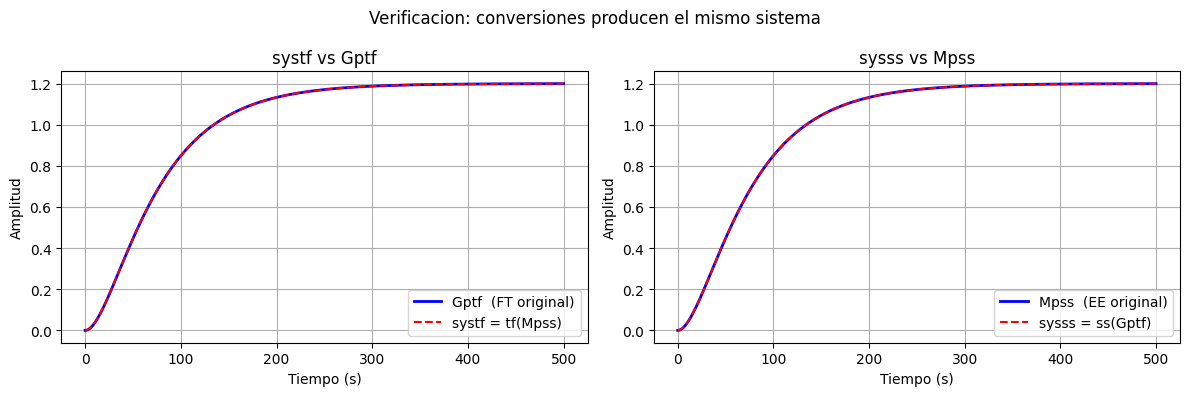


Diferencia maxima |y_Gptf - y_systf|: 1.5543122344752192e-15
Diferencia maxima |y_Mpss - y_sysss|: 6.23945339839338e-14


In [ ]:
# =====================================================================
# 5.4  Conversion entre representaciones
# =====================================================================

# Conversiones principales solicitadas
systf  = sc.tf(Mpss)       # EE  -> FT
sysss  = sc.ss(Gptf)       # FT  -> EE

# --- CORRECCION ---
z = sc.zeros(Gptf)
p = sc.poles(Gptf)
k = sc.dcgain(Gptf)
syszpk = sc.zpk(z, p, k)   # FT -> Ceros-Polos-Ganancia

print('=== systf = sc.tf(Mpss)  (EE -> FT) ===')
print(systf)

print('\n=== sysss = sc.ss(Gptf)  (FT -> EE) ===')
print(sysss)

print('\n=== syszpk = sc.zpk(Gptf)  (FT -> ZPK) ===')
print(syszpk)

# ----- Otras conversiones posibles ----
print('\n=== Otras conversiones ===')
print('ZPK -> EE :', sc.ss(syszpk))
print('ZPK -> FT :', sc.tf(syszpk))
print('EE  -> ZPK:', sc.zpk(sc.zeros(Mpss), sc.poles(Mpss), sc.dcgain(Mpss)))

# =====================================================================
# Verificacion: systf == Gptf?  sysss == Mpss?
# =====================================================================
print('\n=== ¿systf es equivalente a Gptf? ===')
num_Gptf, den_Gptf = sc.tfdata(Gptf)
num_systf, den_systf = sc.tfdata(systf)
print('num Gptf :', np.round(num_Gptf[0][0], 8))
print('num systf:', np.round(num_systf[0][0], 8))
print('den Gptf :', np.round(den_Gptf[0][0], 8))
print('den systf:', np.round(den_systf[0][0], 8))

print('\n=== Verificacion por respuesta al escalon ===')
T_ver = np.linspace(0, 500, 2000)
_, y_Gptf  = sc.step_response(Gptf,  T_ver)
_, y_systf = sc.step_response(systf, T_ver)
_, y_Mpss  = sc.step_response(Mpss,  T_ver)
_, y_sysss = sc.step_response(sysss, T_ver)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(T_ver, y_Gptf,  'b',  linewidth=2,   label='Gptf  (FT original)')
axes[0].plot(T_ver, y_systf, 'r--', linewidth=1.5, label='systf = tf(Mpss)')
axes[0].set_title('systf vs Gptf')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(T_ver, y_Mpss,  'b',  linewidth=2,   label='Mpss  (EE original)')
axes[1].plot(T_ver, y_sysss, 'r--', linewidth=1.5, label='sysss = ss(Gptf)')
axes[1].set_title('sysss vs Mpss')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Verificacion: conversiones producen el mismo sistema', fontsize=12)
plt.tight_layout()
plt.show()

print('\nDiferencia maxima |y_Gptf - y_systf|:', np.max(np.abs(y_Gptf - y_systf)))
print('Diferencia maxima |y_Mpss - y_sysss|:', np.max(np.abs(y_Mpss  - y_sysss)))

## 5.5 Sistema de la figura 5 y SCNR (red abierta)

### 5.5 Respuesta y(t) para u(t)=escalon unitario
Para la figura 5, la salida ante escalon unitario es simplemente la respuesta al escalon de `Gptfm`.

### 5.5.1 Funciones de transferencia en la figura 6 (SCNR)
De la estructura:

$$u(t)=p(t)+m(t), \quad m(t)=G_c(s)e(t), \quad y(t)=G_{ptfm}(s)u(t)$$

se obtiene por superposicion:

$$Y(s)=G_{ptfm}(s)G_c(s)E(s)+G_{ptfm}(s)P(s)$$

Por tanto:

$$Y_r(s)=\frac{Y(s)}{E(s)}=G_c(s)G_{ptfm}(s)$$

$$Y_p(s)=\frac{Y(s)}{P(s)}=G_{ptfm}(s)$$

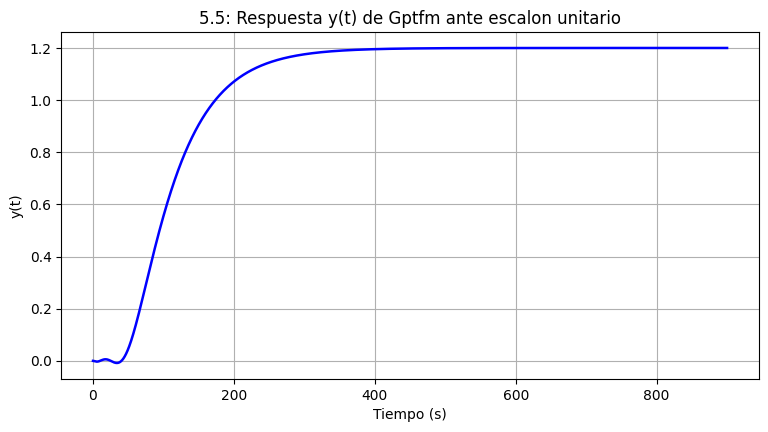

Gctf =
<TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  399.4 s^2 + 24.6 s + 0.3
  ------------------------
         39.2 s + 1

Gatfm (sin simplificar) =
<TransferFunction>: sys[33]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         -479.3 s^5 + 117.2 s^4 - 10.04 s^3 - 0.08766 s^2 + 0.04475 s + 0.0007172
  --------------------------------------------------------------------------------------
  5.219e+04 s^6 + 2.052e+04 s^5 + 3550 s^4 + 319.6 s^3 + 14.09 s^2 + 0.2805 s + 0.001992

Gatfm (minreal) =
<TransferFunction>: sys[34]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   -0.009184 s^3 + 0.002811 s^2 - 0.0003586 s + 1.83e-05
  -------------------------------------------------------
  s^4 + 0.3316 s^3 + 0.04686 s^2 + 0.002988 s + 5.082e-05

Tipo de estructura de Gatfm: TransferFunction


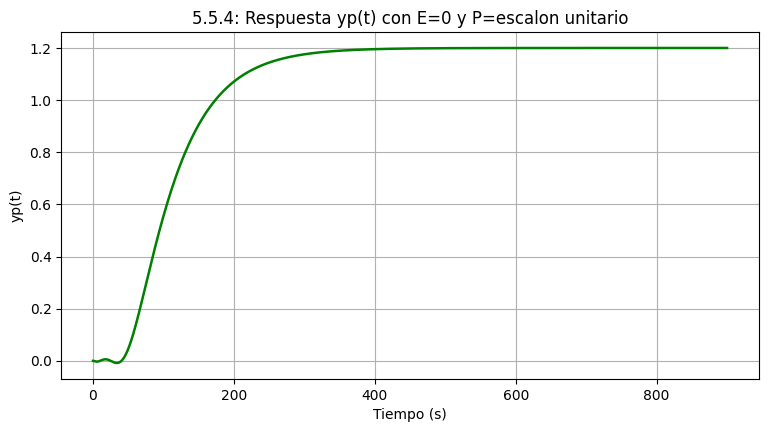

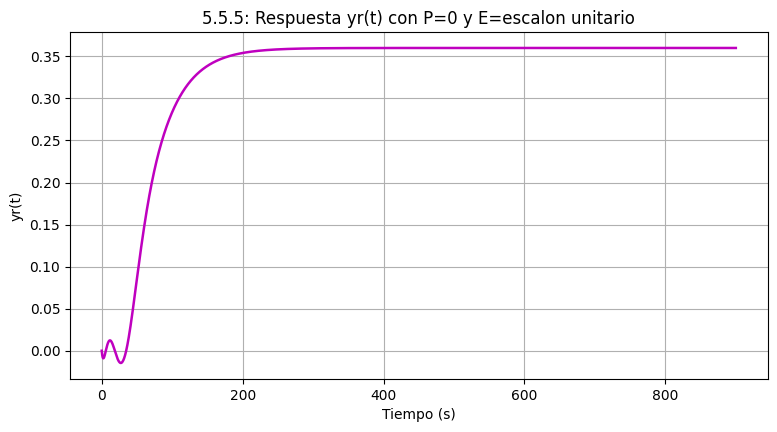


=== Comparacion 5.5.4 vs 5.5.5 ===
Valor final yp (dcgain): 1.200000
Valor final yr (dcgain): 0.360000
Ts yp (2%): 301.723 s
Ts yr (2%): 192.919 s
%OS yp: 0.000
%OS yr: 0.000


In [ ]:
# =====================================================================
# 5.5.0 Respuesta y(t) de Gptfm ante escalon unitario
# =====================================================================
T55 = np.linspace(0, 900, 5000)

Ty, y = sc.step_response(Gptfm, T55)
plt.figure(figsize=(9, 4.5))
plt.plot(Ty, y, 'b', linewidth=1.8)
plt.title('5.5: Respuesta y(t) de Gptfm ante escalon unitario')
plt.xlabel('Tiempo (s)')
plt.ylabel('y(t)')
plt.grid(True)
plt.show()

# =====================================================================
# 5.5.2 Controlador Gctf
# Kc = 0.3, ceros = polos de Gptfm (aprox. de la parte de proceso)
# polo = 1/Tm
# =====================================================================
Kc = 0.3
num_gc = (Kc * np.polymul([tau1, 1], [tau2, 1])).tolist()
den_gc = [Tm, 1]

Gctf = sc.tf(num_gc, den_gc)
print('Gctf =')
print(Gctf)

# =====================================================================
# 5.5.3 Red abierta: Gatfm = Gctf * Gptfm y simplificacion minreal
# =====================================================================
Gatfm_raw = Gctf * Gptfm
Gatfm = sc.minreal(Gatfm_raw, verbose=False)

print('\nGatfm (sin simplificar) =')
print(Gatfm_raw)
print('\nGatfm (minreal) =')
print(Gatfm)
print('\nTipo de estructura de Gatfm:', type(Gatfm).__name__)

# =====================================================================
# 5.5.4 E(s)=0, P(s)=escalon unitario => yp(t)
# Yp(s)=Gptfm(s)
# =====================================================================
Yp = Gptfm
T_yp, yp = sc.step_response(Yp, T55)

plt.figure(figsize=(9, 4.5))
plt.plot(T_yp, yp, 'g', linewidth=1.8)
plt.title('5.5.4: Respuesta yp(t) con E=0 y P=escalon unitario')
plt.xlabel('Tiempo (s)')
plt.ylabel('yp(t)')
plt.grid(True)
plt.show()

# =====================================================================
# 5.5.5 P(s)=0, E(s)=escalon unitario => yr(t)
# Yr(s)=Gatfm(s)
# =====================================================================
Yr = Gatfm
T_yr, yr = sc.step_response(Yr, T55)

plt.figure(figsize=(9, 4.5))
plt.plot(T_yr, yr, 'm', linewidth=1.8)
plt.title('5.5.5: Respuesta yr(t) con P=0 y E=escalon unitario')
plt.xlabel('Tiempo (s)')
plt.ylabel('yr(t)')
plt.grid(True)
plt.show()

# Comparacion cuantitativa entre yp y yr
info_yp = sc.step_info(Yp)
info_yr = sc.step_info(Yr)

print('\n=== Comparacion 5.5.4 vs 5.5.5 ===')
print(f'Valor final yp (dcgain): {float(sc.dcgain(Yp)):.6f}')
print(f'Valor final yr (dcgain): {float(sc.dcgain(Yr)):.6f}')
print(f'Ts yp (2%): {info_yp["SettlingTime"]:.3f} s')
print(f'Ts yr (2%): {info_yr["SettlingTime"]:.3f} s')
print(f'%OS yp: {info_yp["Overshoot"]:.3f}')
print(f'%OS yr: {info_yr["Overshoot"]:.3f}')

## 5.6 Sistema retroalimentado (figura 7)

### 5.6.1 Conversion a EE y funciones en red cerrada
Con:

- `Massm = ss(Gatfm)`
- `Mpssm = ss(Gptfm)`

para realimentacion unitaria negativa se cumple:

$$Y(s)=G_{ref}(s)R(s)+G_{per}(s)P(s)$$

$$G_{ref}(s)=\frac{Y(s)}{R(s)}=\frac{M_{assm}(s)}{1+M_{assm}(s)}$$

$$G_{per}(s)=\frac{Y(s)}{P(s)}=\frac{M_{pssm}(s)}{1+M_{assm}(s)}$$

con $M_{assm}(s)=G_c(s)G_{ptfm}(s)$.

Gref =
<TransferFunction>: sys[46]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -0.009184 s^3 + 0.002811 s^2 - 0.0003586 s + 1.83e-05
  ------------------------------------------------------
  s^4 + 0.3224 s^3 + 0.04967 s^2 + 0.00263 s + 6.912e-05

Gper =
<TransferFunction>: sys[52]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  7.772e-16 s^5 - 0.0009014 s^4 + 0.0002529 s^3 - 2.816e-05 s^2 + 8.978e-07 s + 4.581e-08
  ---------------------------------------------------------------------------------------
  s^6 + 0.384 s^5 + 0.07028 s^4 + 0.005931 s^3 + 0.0002684 s^2 + 6.232e-06 s + 5.192e-08


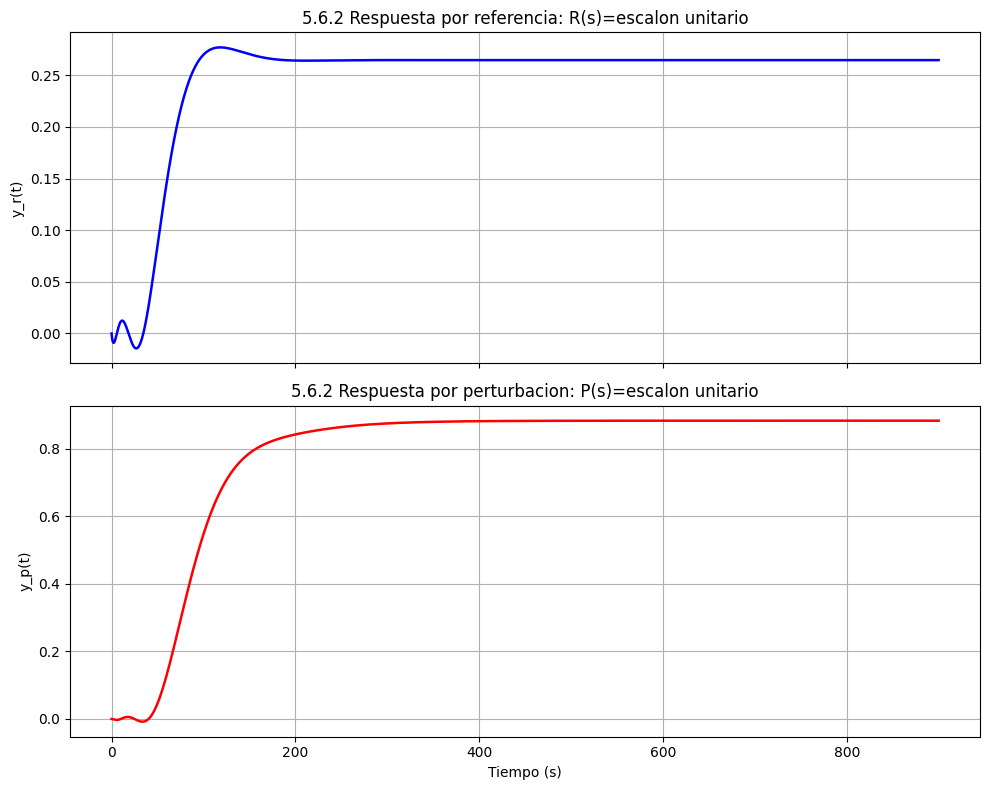


=== Metricas 5.6.2 ===
Gref -> valor final: 0.264706, Ts: 152.345 s, %OS: 4.661
Gper -> valor final: 0.882353, Ts: 255.033 s, %OS: 0.000


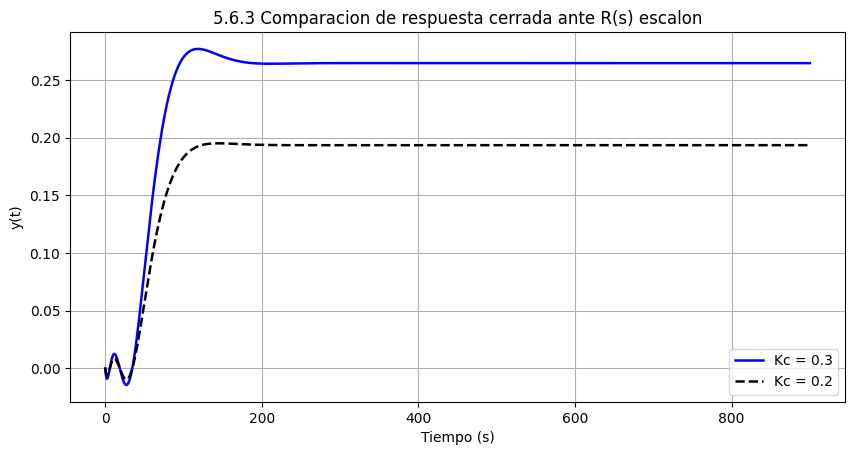


=== Comparacion Kc=0.3 vs Kc=0.2 (entrada de referencia) ===
Kc=0.3 -> final: 0.264706, Ts: 152.345, %OS: 4.661
Kc=0.2 -> final: 0.193548, Ts: 111.076, %OS: 0.832
Conclusión preliminar: Kc=0.2 mejora transitorio sin penalizar sobreimpulso.


In [ ]:
# =====================================================================
# 5.6.1 Modelos EE y funciones de red cerrada
# =====================================================================
Massm = sc.ss(Gatfm)
Mpssm = sc.ss(Gptfm)

# Gref = Y/R, Gper = Y/P
Gref = sc.minreal(sc.tf(sc.feedback(Massm, 1)), verbose=False)
Gper = sc.minreal(sc.tf(Mpssm / (1 + Massm)), verbose=False)

print('Gref =')
print(Gref)
print('\nGper =')
print(Gper)

# =====================================================================
# 5.6.2 Respuestas a escalon unitario para R y P (subplot vertical)
# =====================================================================
T56 = np.linspace(0, 900, 5000)

T_r, y_r = sc.step_response(Gref, T56)
T_p, y_p = sc.step_response(Gper, T56)

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(T_r, y_r, 'b', linewidth=1.8)
ax[0].set_title('5.6.2 Respuesta por referencia: R(s)=escalon unitario')
ax[0].set_ylabel('y_r(t)')
ax[0].grid(True)

ax[1].plot(T_p, y_p, 'r', linewidth=1.8)
ax[1].set_title('5.6.2 Respuesta por perturbacion: P(s)=escalon unitario')
ax[1].set_xlabel('Tiempo (s)')
ax[1].set_ylabel('y_p(t)')
ax[1].grid(True)

plt.tight_layout()
plt.show()

info_r = sc.step_info(Gref)
info_p = sc.step_info(Gper)

print('\n=== Metricas 5.6.2 ===')
print(f'Gref -> valor final: {float(sc.dcgain(Gref)):.6f}, Ts: {info_r["SettlingTime"]:.3f} s, %OS: {info_r["Overshoot"]:.3f}')
print(f'Gper -> valor final: {float(sc.dcgain(Gper)):.6f}, Ts: {info_p["SettlingTime"]:.3f} s, %OS: {info_p["Overshoot"]:.3f}')

# =====================================================================
# 5.6.3 Ganancia del controlador Kc=0.2 y comparacion
# =====================================================================
Kc2 = 0.2
num_gc2 = (Kc2 * np.polymul([tau1, 1], [tau2, 1])).tolist()
den_gc2 = [Tm, 1]

Gctf2 = sc.tf(num_gc2, den_gc2)
Gatfm2 = sc.minreal(Gctf2 * Gptfm, verbose=False)
Massm2 = sc.ss(Gatfm2)
Mpssm2 = sc.ss(Gptfm)

Gref2 = sc.minreal(sc.tf(sc.feedback(Massm2, 1)), verbose=False)
Gper2 = sc.minreal(sc.tf(Mpssm2 / (1 + Massm2)), verbose=False)

T_r2, y_r2 = sc.step_response(Gref2, T56)

plt.figure(figsize=(10, 4.8))
plt.plot(T_r, y_r, 'b', linewidth=1.8, label='Kc = 0.3')
plt.plot(T_r2, y_r2, 'k--', linewidth=1.8, label='Kc = 0.2')
plt.title('5.6.3 Comparacion de respuesta cerrada ante R(s) escalon')
plt.xlabel('Tiempo (s)')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.show()

info_r2 = sc.step_info(Gref2)
print('\n=== Comparacion Kc=0.3 vs Kc=0.2 (entrada de referencia) ===')
print(f'Kc=0.3 -> final: {float(sc.dcgain(Gref)):.6f}, Ts: {info_r["SettlingTime"]:.3f}, %OS: {info_r["Overshoot"]:.3f}')
print(f'Kc=0.2 -> final: {float(sc.dcgain(Gref2)):.6f}, Ts: {info_r2["SettlingTime"]:.3f}, %OS: {info_r2["Overshoot"]:.3f}')

# Comentario rapido automatico
if info_r2['SettlingTime'] < info_r['SettlingTime'] and info_r2['Overshoot'] <= info_r['Overshoot']:
    print('Conclusión preliminar: Kc=0.2 mejora transitorio sin penalizar sobreimpulso.')
elif info_r2['SettlingTime'] > info_r['SettlingTime'] and info_r2['Overshoot'] <= info_r['Overshoot']:
    print('Conclusión preliminar: Kc=0.2 es mas conservador (menos agresivo), pero mas lento.')
else:
    print('Conclusión preliminar: comparar segun criterio (rapidez vs sobreimpulso/error).')